# 02 — Input bit-depth sweep (PyTorch)

Sweeps input quantization in [0,2,4,8] with fixed network precision.

In [3]:
from pathlib import Path
import sys, os

# ---- Path setup (adjust if your repo layout differs) ----
PROJECT_ROOT = Path("..").resolve()
SRC = PROJECT_ROOT / "src"
if str(SRC) not in sys.path:
    sys.path.insert(0, str(SRC))

In [4]:
import pandas as pd

from config import ExperimentConfig, with_overrides
from runner import run_experiment
from utils import load_runs, flatten_runs

pd.set_option("display.max_columns", 200)


In [5]:

base = ExperimentConfig(
    backend="pytorch",
    device="cuda",
    batch_size=1,       
    seed=42,
    num_eval_batches=500,
)

in_bits_list = [4, 2, 1] 


In [6]:
cfgs32 = [with_overrides(base, input_quant_bits=b, model_precision="fp32") for b in in_bits_list]

records = []
for cfg in cfgs32:
    payload, _ = run_experiment(cfg, split="val", save_results_flag=True)
    records.append(payload)

for r in records:
    print(r["run_id"], r["status"], r["results"].get("top1_acc"))

[data] Filtered to 5000 samples across 100 classes.
Evaluating on 500 batches (first 30 are warmup)...
  --- Warmup complete (30 batches) — starting metric collection ---
  Batch [40/500] Top-1: 90.00% | Top-5: 100.00% | Infer: 3.29 ms/batch
  Batch [50/500] Top-1: 95.00% | Top-5: 100.00% | Infer: 3.00 ms/batch
  Batch [60/500] Top-1: 96.67% | Top-5: 100.00% | Infer: 2.84 ms/batch
  Batch [70/500] Top-1: 97.50% | Top-5: 100.00% | Infer: 2.80 ms/batch
  Batch [80/500] Top-1: 94.00% | Top-5: 98.00% | Infer: 2.72 ms/batch
  Batch [90/500] Top-1: 93.33% | Top-5: 98.33% | Infer: 2.77 ms/batch
  Batch [100/500] Top-1: 94.29% | Top-5: 98.57% | Infer: 2.71 ms/batch
  Batch [110/500] Top-1: 93.75% | Top-5: 98.75% | Infer: 2.73 ms/batch
  Batch [120/500] Top-1: 92.22% | Top-5: 98.89% | Infer: 2.71 ms/batch
  Batch [130/500] Top-1: 92.00% | Top-5: 99.00% | Infer: 2.73 ms/batch
  Batch [140/500] Top-1: 90.91% | Top-5: 99.09% | Infer: 2.73 ms/batch
  Batch [150/500] Top-1: 89.17% | Top-5: 99.17% | 

In [7]:
runs = load_runs("../runs", status="ok")
rows = flatten_runs(runs)
df = pd.DataFrame(rows)

# Filter only what this notebook is responsible for
df_sweep = df[
    (df["cfg.backend"] == "pytorch")
    & (df["cfg.device"] == "cuda")
    & (df["cfg.model_precision"].isin(["fp32"])) 
    & (df["cfg.input_quant_bits"].isin([8, 4, 2, 1]))
].copy()

df_sweep[[
    "run_id",
    "res.top1_acc",
    "res.top5_acc",
    "res.infer_ms_avg",
    "res.throughput_infer_sps",
    "res.total_samples",
]].sort_values(["run_id"])

,run_id,res.top1_acc,res.top5_acc,res.infer_ms_avg,res.throughput_infer_sps,res.total_samples
1,resnet18_pytorch_fp32_in1b_cuda_bs1,26.595745,56.595745,2.869502,348.492504,470
2,resnet18_pytorch_fp32_in2b_cuda_bs1,49.787234,77.659574,2.818630,354.782249,470
3,resnet18_pytorch_fp32_in4b_cuda_bs1,80.851064,96.170213,2.698732,370.544390,470
4,resnet18_pytorch_fp32_in8b_cuda_bs1,83.829787,96.595745,3.093748,323.232546,470


In [8]:
cfgs16 = [with_overrides(base, input_quant_bits=b, model_precision="fp16") for b in in_bits_list]

records = []
for cfg in cfgs16:
    payload, _ = run_experiment(cfg, split="val", save_results_flag=True)
    records.append(payload)

for r in records:
    print(r["run_id"], r["status"], r["results"].get("top1_acc"))

[data] Filtered to 5000 samples across 100 classes.
Evaluating on 500 batches (first 30 are warmup)...
  --- Warmup complete (30 batches) — starting metric collection ---
  Batch [40/500] Top-1: 90.00% | Top-5: 100.00% | Infer: 4.16 ms/batch
  Batch [50/500] Top-1: 95.00% | Top-5: 100.00% | Infer: 3.46 ms/batch
  Batch [60/500] Top-1: 96.67% | Top-5: 100.00% | Infer: 3.15 ms/batch
  Batch [70/500] Top-1: 97.50% | Top-5: 100.00% | Infer: 3.01 ms/batch
  Batch [80/500] Top-1: 94.00% | Top-5: 98.00% | Infer: 2.95 ms/batch
  Batch [90/500] Top-1: 93.33% | Top-5: 98.33% | Infer: 3.04 ms/batch
  Batch [100/500] Top-1: 94.29% | Top-5: 98.57% | Infer: 3.00 ms/batch
  Batch [110/500] Top-1: 93.75% | Top-5: 98.75% | Infer: 3.06 ms/batch
  Batch [120/500] Top-1: 92.22% | Top-5: 98.89% | Infer: 2.98 ms/batch
  Batch [130/500] Top-1: 92.00% | Top-5: 99.00% | Infer: 2.95 ms/batch
  Batch [140/500] Top-1: 90.91% | Top-5: 99.09% | Infer: 2.96 ms/batch
  Batch [150/500] Top-1: 89.17% | Top-5: 99.17% | 

In [9]:
runs = load_runs("../runs", status="ok")
rows = flatten_runs(runs)
df = pd.DataFrame(rows)

# Filter only what this notebook is responsible for
df_sweep = df[
    (df["cfg.backend"] == "pytorch")
    & (df["cfg.device"] == "cuda")
    & (df["cfg.model_precision"].isin(["fp16"])) 
    & (df["cfg.input_quant_bits"].isin([8, 4, 2, 1]))
].copy()

df_sweep[[
    "run_id",
    "res.top1_acc",
    "res.top5_acc",
    "res.infer_ms_avg",
    "res.throughput_infer_sps",
    "res.total_samples",
]].sort_values(["run_id"])

,run_id,res.top1_acc,res.top5_acc,res.infer_ms_avg,res.throughput_infer_sps,res.total_samples
0,resnet18_pytorch_fp16_in1b_cuda_bs1,26.595745,56.595745,2.782924,359.334227,470
1,resnet18_pytorch_fp16_in2b_cuda_bs1,49.787234,77.659574,2.688799,371.913222,470
2,resnet18_pytorch_fp16_in4b_cuda_bs1,80.638298,96.170213,2.809120,355.983392,470
3,resnet18_pytorch_fp16_in8b_cuda_bs1,83.829787,96.595745,2.885167,346.600371,470


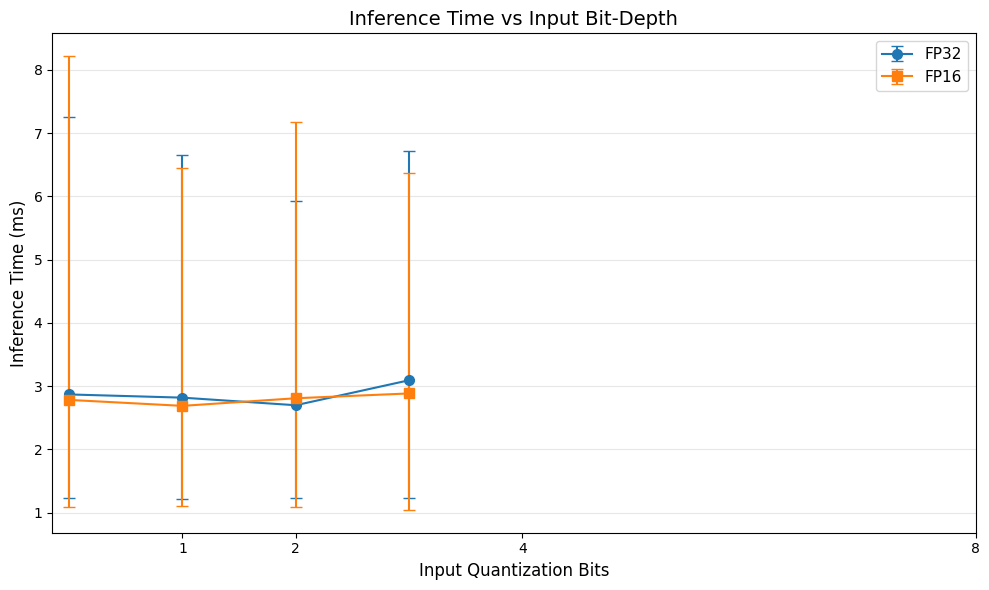

In [10]:
import matplotlib.pyplot as plt

runs = load_runs("../runs", status="ok")
rows = flatten_runs(runs)
df = pd.DataFrame(rows)

# Filter base conditions
base_filter = (df["cfg.backend"] == "pytorch") & (df["cfg.input_quant_bits"].isin([8, 4, 2, 1]))

plt.figure(figsize=(10, 6))

bit_values = sorted(df[base_filter]["cfg.input_quant_bits"].unique())

for precision, marker in [("fp32", "o"), ("fp16", "s")]:
    df_filtered = df[base_filter & (df["cfg.model_precision"] == precision)].sort_values("cfg.input_quant_bits")
    avgs = df_filtered["res.infer_ms_avg"].values
    mins = df_filtered["res.infer_ms_min"].values
    maxs = df_filtered["res.infer_ms_max"].values
    x_vals = [list(bit_values).index(b) for b in df_filtered["cfg.input_quant_bits"].values]

    plt.errorbar(x_vals, avgs, yerr=[avgs - mins, maxs - avgs], marker=marker,
                 capsize=4, linewidth=1.5, markersize=7, label=precision.upper())

plt.xlabel("Input Quantization Bits", fontsize=12)
plt.ylabel("Inference Time (ms)", fontsize=12)
plt.title("Inference Time vs Input Bit-Depth", fontsize=14)
plt.xticks(bit_values)
plt.legend(fontsize=11)
plt.grid(True, alpha=0.3, axis='y')
plt.tight_layout()
plt.savefig("inference_time_vs_bits.pdf", backend='pdf')
plt.show()

In [11]:
#accuracy is same for both fp16 and fp32